# Paper figures — 3 targeted plots for the results section

Each cell produces one self-contained figure ready for LaTeX.
Saved to `figs_paper/` as high-resolution PNGs.

- **Figure 1** — Aggregator × optimizer interaction with/without FedProx (heatmaps)
- **Figure 2** — Gradient divergence ≠ convergence quality (plateau curves + scatter)
- **Figure 3** — Heterogeneity hurts; FL vs centralized baseline by optimizer

## Setup & data loading

In [1]:
import json
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

# Publication-quality defaults
plt.rcParams.update({
    "figure.dpi":        150,
    "font.size":         9,
    "axes.titlesize":    10,
    "axes.labelsize":    9,
    "legend.fontsize":   8,
    "xtick.labelsize":   8,
    "ytick.labelsize":   8,
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "axes.grid":         True,
    "grid.alpha":        0.3,
    "grid.linewidth":    0.5,
})
sns.set_palette("tab10")

RESULTS_DIR = Path("results")   # ← adjust if needed
FIGS_DIR    = Path("figs_paper")
FIGS_DIR.mkdir(exist_ok=True)

In [2]:
# ── Load all results ────────────────────────────────────────────────────────
records = []
for d in sorted(RESULTS_DIR.iterdir()):
    p = d / "history.json"
    if d.is_dir() and p.exists():
        data = json.loads(p.read_text())
        data["exp_id"] = d.name
        records.append(data)
print(f"Loaded {len(records)} experiments")

def dist_label(cfg):
    d = cfg.get("data_distribution", "?")
    return f"Dir. α={cfg['dirichlet_alpha']}" if d == "dirichlet" else d.replace("_", "-")

def fine_group(opt, reg, agg):
    """6-way split: (FedAvg|FedAdam) × (adam(w) ±FedProx) + SGD bucket."""
    if opt == "sgd":
        return "SGD"
    agg_label = "FedAdam" if agg == "fedadam" else "FedAvg"
    reg_label  = "FedProx" if reg == "fedprox" else "no FedProx"
    return f"{agg_label} + adam(w), {reg_label}"

# ── Summary DataFrame ────────────────────────────────────────────────────────
rows = []
for r in records:
    cfg, h, bh = r["config"], r["history"], r.get("baseline_history") or {}
    gvl = h.get("global_val_loss", [])
    gd  = h.get("grad_divergence", [])
    reg = cfg.get("client_regularization") or "none"
    opt = cfg.get("optimizer")
    agg = cfg.get("aggregator")
    rows.append({
        "exp_id":           r["exp_id"],
        "num_clients":      cfg["num_clients"],
        "distribution":     cfg["data_distribution"],
        "dist_label":       dist_label(cfg),
        "dirichlet_alpha":  cfg["dirichlet_alpha"],
        "aggregator":       agg,
        "regularization":   reg,
        "optimizer":        opt,
        "opt_label":        "adam(w)" if opt in ("adamw","adam") else "SGD",
        "fine_group":       fine_group(opt, reg, agg),
        "final_global_val": gvl[-1]  if gvl else np.nan,
        "mean_grad_div":    np.mean(gd) if gd else np.nan,
        "final_grad_div":   gd[-1]  if gd else np.nan,
        "baseline_final_val": (bh.get("val_loss") or [np.nan])[-1],
    })

df = pd.DataFrame(rows)
df["fl_vs_baseline"] = df["final_global_val"] - df["baseline_final_val"]
df["clients_label"]  = df["num_clients"].astype(str) + " clients"

# ── Long-format for curves ───────────────────────────────────────────────────
META = ["num_clients","clients_label","distribution","dist_label",
        "aggregator","regularization","optimizer","opt_label","fine_group"]
curve_rows, div_rows = [], []
for r in records:
    h, exp_id = r["history"], r["exp_id"]
    meta = df.loc[df["exp_id"]==exp_id, META].iloc[0].to_dict()
    gvl = h.get("global_val_loss", [])
    er  = h.get("eval_rounds", list(range(1, len(gvl)+1)))
    for rnd, v in zip(er, gvl):
        curve_rows.append({"round": rnd, "global_val_loss": v, **meta})
    for i, v in enumerate(h.get("grad_divergence", [])):
        div_rows.append({"round": i+1, "grad_divergence": v, **meta})

df_curves = pd.DataFrame(curve_rows)
df_div    = pd.DataFrame(div_rows)
print(f"Summary: {df.shape} | Curves: {df_curves.shape} | Divergence: {df_div.shape}")
print("fine_group values:", sorted(df["fine_group"].unique()))


Loaded 120 experiments
Summary: (120, 16) | Curves: (2400, 11) | Divergence: (2400, 11)
fine_group values: ['FedAdam + adam(w), FedProx', 'FedAdam + adam(w), no FedProx', 'FedAvg + adam(w), FedProx', 'FedAvg + adam(w), no FedProx', 'SGD']


## Figure 1 — Aggregator × Optimizer interaction with/without FedProx

**Claim**: FedProx reverses the FedAvg / FedAdam ranking for adaptive optimizers.
Without FedProx, FedAvg outperforms FedAdam for adam(w); with FedProx, the order flips and FedAdam wins.
SGD is unaffected by FedProx in both cases.

Two side-by-side heatmaps share a colour scale so the reversal in the adam(w) column
is immediately visible.

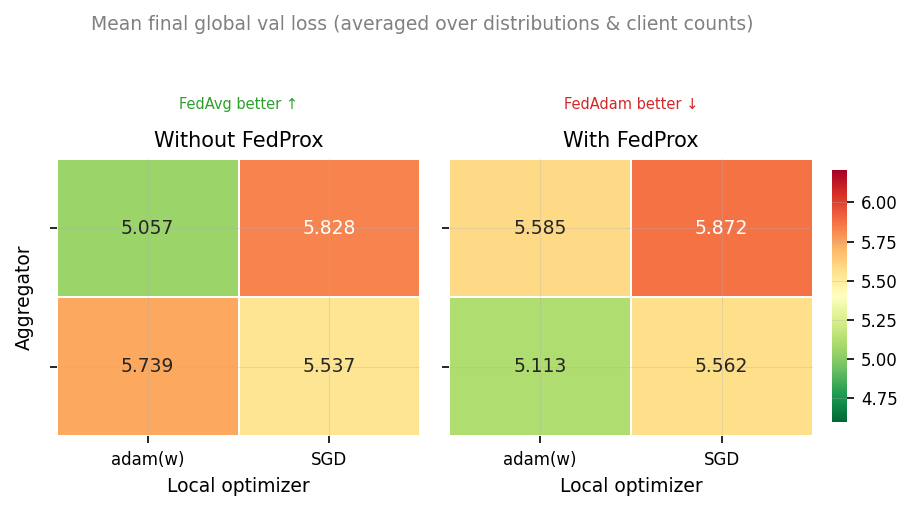

Saved fig1


In [3]:
VMIN = df["final_global_val"].quantile(0.05)
VMAX = df["final_global_val"].quantile(0.95)
OPT_ORDER = ["adam(w)", "SGD"]
AGG_ORDER = ["fedavg", "fedadam"]

fig, axes = plt.subplots(1, 2, figsize=(6.5, 2.4), sharey=True)
fig.subplots_adjust(wspace=0.08)

for ax, (reg, title) in zip(axes, [("none", "Without FedProx"),
                                     ("fedprox", "With FedProx")]):
    pivot = (df[df["regularization"] == reg]
               .pivot_table("final_global_val", "aggregator", "opt_label", aggfunc="mean")
               .reindex(index=AGG_ORDER, columns=OPT_ORDER))
    cbar_ax = fig.add_axes([0.92, 0.15, 0.015, 0.7]) if ax is axes[1] else None
    sns.heatmap(pivot, annot=True, fmt=".3f", cmap="RdYlGn_r",
                linewidths=0.8, linecolor="white",
                vmin=VMIN, vmax=VMAX,
                cbar=(ax is axes[1]), cbar_ax=cbar_ax,
                ax=ax, annot_kws={"size": 9})
    ax.set_title(title, pad=6)
    ax.set_xlabel("Local optimizer")
    ax.set_ylabel("Aggregator" if ax is axes[0] else "")
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=0)

# Annotate the flip in the adam(w) column
axes[0].annotate("FedAvg better ↑", xy=(0.5, 1.0), xycoords="axes fraction",
                 xytext=(0.5, 1.18), fontsize=7, ha="center", color="#2ca02c",)
                 #arrowprops=dict(arrowstyle="-", color="#2ca02c", lw=0.8))
axes[1].annotate("FedAdam better ↓", xy=(0.5, 1.0), xycoords="axes fraction",
                 xytext=(0.5, 1.18), fontsize=7, ha="center", color="#d62728",)
                 #arrowprops=dict(arrowstyle="-", color="#d62728", lw=0.8))

fig.suptitle("Mean final global val loss (averaged over distributions & client counts)",
             y=1.28, fontsize=9, color="gray")
plt.savefig(FIGS_DIR / "fig1_heatmap_fedprox_interaction.png",
            bbox_inches="tight", dpi=200)
plt.show()
print("Saved fig1")

In [4]:
# Supporting numbers for the text
for nc in [4, 32]:
    print(f"\n── {nc} clients ──")
    sub = df[df["num_clients"]==nc]
    tbl = (sub.groupby(["regularization","aggregator","opt_label"])["final_global_val"]
              .mean().unstack(["aggregator","opt_label"]).round(4))
    print(tbl.to_string())


── 4 clients ──
aggregator     fedadam          fedavg        
opt_label          SGD adam(w)     SGD adam(w)
regularization                                
fedprox         5.5848  4.9714  5.7036  5.3492
none            5.5571  5.2612  5.6589  4.6703

── 32 clients ──
aggregator     fedadam          fedavg        
opt_label          SGD adam(w)     SGD adam(w)
regularization                                
fedprox         5.5382  5.2555  6.0413  5.8217
none            5.5179  6.2163  5.9972  5.4430


## Figure 2 — Gradient divergence does not predict convergence quality

**Claim**: The relationship between gradient divergence and convergence quality
depends on the aggregator. With FedAdam, adding FedProx *increases* gradient
divergence yet *improves* validation loss — a clear decoupling. With FedAvg,
FedProx leaves divergence unchanged while worsening validation loss.

**Panel A**: Divergence trajectories, faceted by aggregator.
Each panel has three lines: adam(w) ±FedProx and SGD (aggregated).
The FedProx effect on divergence is aggregator-specific.

**Panel B**: Scatter of mean gradient divergence vs final val loss,
adam(w) experiments only. Marker = aggregator; colour = FedProx on/off.
The FedAdam+FedProx cluster (high div, lower val loss) is the key counterexample.


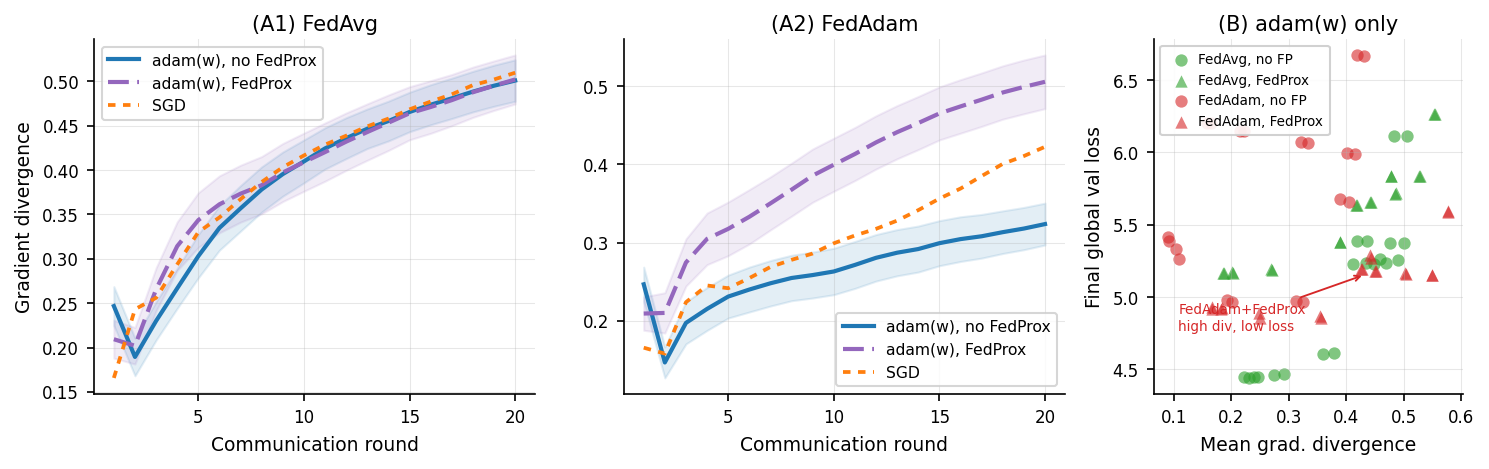

Saved fig2


In [5]:
# ── Colour / style maps ─────────────────────────────────────────────────────
FP_COLOR  = {"no FedProx": "#1f77b4", "FedProx": "#9467bd"}  # blue / purple
SGD_COLOR = "#ff7f0e"
AGG_COLOR = {"fedavg": "#2ca02c", "fedadam": "#d62728"}       # green / red
REG_MARKER= {"none": "o", "fedprox": "^"}

# ── Panel A: divergence curves, faceted by aggregator ───────────────────────
fig, axes = plt.subplots(1, 3, figsize=(10, 3.2),
                         gridspec_kw={"width_ratios": [2, 2, 1.4]})

for ax, agg in zip(axes[:2], ["fedavg", "fedadam"]):
    agg_label = "FedAvg" if agg == "fedavg" else "FedAdam"
    sub = df_div[df_div["aggregator"] == agg]

    # adam(w) lines — split by FedProx
    for reg_label, ls in [("no FedProx", "solid"), ("FedProx", (0,(5,2)))]:
        grp_name = f"{agg_label} + adam(w), {reg_label}"
        s = sub[sub["fine_group"] == grp_name]
        agg_s = s.groupby("round")["grad_divergence"].agg(["mean","sem"])
        x = agg_s.index.values
        ax.plot(x, agg_s["mean"], color=FP_COLOR[reg_label], lw=2,
                linestyle=ls, label=f"adam(w), {reg_label}")
        ax.fill_between(x, agg_s["mean"]-agg_s["sem"],
                            agg_s["mean"]+agg_s["sem"],
                        color=FP_COLOR[reg_label], alpha=0.12)

    # SGD line (aggregated over FedProx for this aggregator)
    sgd_s = sub[sub["opt_label"] == "SGD"]
    agg_sgd = sgd_s.groupby("round")["grad_divergence"].agg(["mean","sem"])
    ax.plot(agg_sgd.index.values, agg_sgd["mean"],
            color=SGD_COLOR, lw=1.8, linestyle=(0,(2,2)), label="SGD")

    ax.set_title(f"(A{1 if agg=='fedavg' else 2}) {agg_label}", pad=4)
    ax.set_xlabel("Communication round")
    ax.set_ylabel("Gradient divergence" if agg == "fedavg" else "")
    ax.legend(fontsize=7.5, loc="upper left" if agg=="fedavg" else "lower right")

# ── Panel B: scatter — adam(w) only, agg × FedProx ──────────────────────────
ax = axes[2]
sub_adam = df[df["opt_label"] == "adam(w)"]

for agg in ["fedavg", "fedadam"]:
    for reg, marker in REG_MARKER.items():
        mask = (sub_adam["aggregator"]==agg) & (sub_adam["regularization"]==reg)
        s    = sub_adam[mask]
        reg_label = "FedProx" if reg=="fedprox" else "no FP"
        agg_label = "FedAvg" if agg=="fedavg" else "FedAdam"
        ax.scatter(s["mean_grad_div"], s["final_global_val"],
                   color=AGG_COLOR[agg], marker=marker,
                   s=35, alpha=0.6, linewidths=0,
                   label=f"{agg_label}, {reg_label}")

ax.set_xlabel("Mean grad. divergence")
ax.set_ylabel("Final global val loss")
ax.set_title("(B) adam(w) only", pad=4)

# Annotate the FedAdam+FedProx paradox cluster
paradox = sub_adam[(sub_adam["aggregator"]=="fedadam") &
                   (sub_adam["regularization"]=="fedprox")]
ax.annotate("FedAdam+FedProx\nhigh div, low loss",
            xy=(paradox["mean_grad_div"].median(),
                paradox["final_global_val"].median()),
            xytext=(0.08, 0.18), textcoords="axes fraction", fontsize=6.5,
            color=AGG_COLOR["fedadam"],
            arrowprops=dict(arrowstyle="->", color=AGG_COLOR["fedadam"], lw=0.9))

ax.legend(fontsize=6.5, loc="upper left", framealpha=0.9,
          handletextpad=0.3, borderpad=0.5)

plt.tight_layout()
plt.savefig(FIGS_DIR / "fig2_divergence_decoupled.png", bbox_inches="tight", dpi=200)
plt.show()
print("Saved fig2")


## Figure 3 — Heterogeneity hurts; FL vs centralized baseline

**Claim A**: More heterogeneous distributions consistently increase validation loss,
and 32 clients always underperform 4 clients.

**Claim B**: The optimizer matters more for centralized training than for FL.
SGD narrows the FL–baseline gap (SGD baseline is already weak); adam(w) widens it
(a strong centralized optimizer that FL cannot match, especially at 32 clients).

/var/folders/zv/j4ccch2s2550_hm10pnndd5c0000gn/T/ipykernel_66297/1142046793.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=25, ha="right")


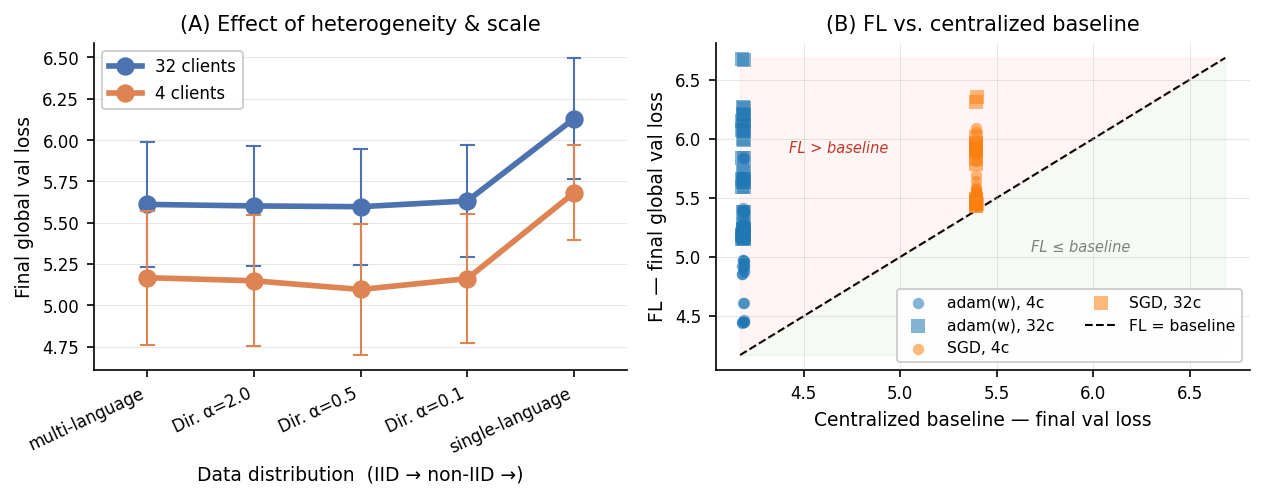

Saved fig3


In [6]:
# Distribution order: IID → non-IID
DIST_ORDER_PLOT = ["multi-language", "Dir. α=2.0", "Dir. α=0.5",
                   "Dir. α=0.1", "single-language"]

fig, axes = plt.subplots(1, 2, figsize=(8.5, 3.4))

# ── Panel A: heterogeneity effect ─────────────────────────────────────────
ax = axes[0]
sns.pointplot(data=df, x="dist_label", y="final_global_val",
            hue="clients_label", order=DIST_ORDER_PLOT,
            errorbar="sd", capsize=0.12, err_kws={"linewidth":1},
            palette=["#4C72B0","#DD8452"], ax=ax)
ax.set_xlabel("Data distribution  (IID → non-IID →)", labelpad=4)
ax.set_ylabel("Final global val loss")
ax.set_title("(A) Effect of heterogeneity & scale")
ax.set_xticklabels(ax.get_xticklabels(), rotation=25, ha="right")
ax.legend(title="", framealpha=0.9)

# ── Panel B: FL vs baseline, by optimizer ────────────────────────────────
ax = axes[1]
sub = df.dropna(subset=["baseline_final_val","final_global_val"])

opt_colors  = {"adam(w)": "#1f77b4", "SGD": "#ff7f0e"}
nc_markers  = {4: "o", 32: "s"}
nc_sizes    = {4: 30, 32: 50}

for opt in ["adam(w)", "SGD"]:
    for nc in [4, 32]:
        mask = (sub["opt_label"]==opt) & (sub["num_clients"]==nc)
        ax.scatter(sub[mask]["baseline_final_val"], sub[mask]["final_global_val"],
                   color=opt_colors[opt], marker=nc_markers[nc],
                   s=nc_sizes[nc], alpha=0.55, linewidths=0,
                   label=f"{opt}, {nc}c")

lo = sub[["baseline_final_val","final_global_val"]].min().min() - 0.01
hi = sub[["baseline_final_val","final_global_val"]].max().max() + 0.01
ax.plot([lo, hi], [lo, hi], "k--", lw=1, zorder=0, label="FL = baseline")

ax.set_xlabel("Centralized baseline — final val loss")
ax.set_ylabel("FL — final global val loss")
ax.set_title("(B) FL vs. centralized baseline")
ax.legend(fontsize=7.5, ncol=2, framealpha=0.9, loc="lower right")

# Shade the "FL worse" region
ax.fill_between([lo, hi], [lo, hi], [hi, hi], alpha=0.04, color="red",
                label=None, zorder=0)
ax.fill_between([lo, hi], [lo, hi], [lo, lo], alpha=0.04, color="green",
                label=None, zorder=0)
ax.text(lo + (hi-lo)*0.6, lo + (hi-lo)*0.35,
        "FL ≤ baseline", fontsize=7, color="gray", style="italic")
ax.text(lo + (hi-lo)*0.1, lo + (hi-lo)*0.68,
        "FL > baseline", fontsize=7, color="#c0392b", style="italic")

plt.tight_layout()
plt.savefig(FIGS_DIR / "fig3_heterogeneity_baseline.png", bbox_inches="tight", dpi=200)
plt.show()
print("Saved fig3")

In [7]:
# Key numbers to quote in the text
print("=== Numbers for the text ===\n")

# A: best vs worst distribution (averaged over all configs)
g = df.groupby("dist_label")["final_global_val"].mean()
print("Mean final val by distribution:")
print(g.reindex(DIST_ORDER_PLOT).round(4).to_string())

# B: 4 vs 32 clients
print("\nMean final val by num_clients:")
print(df.groupby("num_clients")["final_global_val"].mean().round(4).to_string())

# C: how many FL runs beat baseline?
print("\nFL ≤ baseline (by optimizer):")
print(df.groupby("opt_label").apply(lambda x:(x["fl_vs_baseline"]<0).sum())
        .rename("n_better").to_string())

# D: FL-baseline gap by optimizer
print("\nMean FL-baseline gap (positive = FL worse):")
print(df.groupby("opt_label")["fl_vs_baseline"].mean().round(4).to_string())

=== Numbers for the text ===

Mean final val by distribution:
dist_label
multi-language     5.3888
Dir. α=2.0         5.3749
Dir. α=0.5         5.3462
Dir. α=0.1         5.3966
single-language    5.9052

Mean final val by num_clients:
num_clients
4     5.2507
32    5.7140

FL ≤ baseline (by optimizer):
opt_label
SGD        0
adam(w)    0

Mean FL-baseline gap (positive = FL worse):
opt_label
SGD        0.3071
adam(w)    1.1875
